**4697566D  Exploratory Data Analysis and Training with Sagemaker MLFlow Application ARN **

This notebook objective is to conduct experiment on machine learning model to find the best performance model for rent prices of condominiums and apartments in Singapore between year February 2021 and December 2025.

1. Data Source : Compile csv file from URA source "https://eservice.ura.gov.sg/property-market-information/pmiResidentialRentalSearch".
2. Experiment Tracking : Train models on different machine algorithms using MLflow.
3. Model Registration : Register the best-performing model to the MLflow Registry.

**1. Setup and Configuration**

Install the necessary libraries and configure environment


In [1]:
%pip -q install boto3 "sagemaker<3.0.0" mlflow scikit-learn xgboost sagemaker-mlflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os

metadata_path = "/opt/ml/metadata/resource-metadata.json"

if os.path.exists(metadata_path):
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
        
    # This retrieves the SageMaker Studio User Profile name
    user_profile = metadata.get("UserProfileName")
    print(f"User Profile / Team: {user_profile}")
else:
    print("Not running inside a standard SageMaker Studio environment container.")


User Profile / Team: team08-s801


In [3]:
from sagemaker.utils import unique_name_from_base

# Generate a unique session ID or append it to your prefix
session_id = unique_name_from_base("sess") 
print("Session ID: ", session_id)  # Output example: sess-2026-07-08-15-42-01-123

# Example usage with your prefix:
prefix = f"{user_profile}-sgp-rent/{session_id}"


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Session ID:  sess-1787744387-0f13


**Data Preparation - clean raw data,remove lines with missing data, rename columns and reformat variables**

In [4]:
# 1. Initialize SageMaker Session and S3 Bucket Details
import os
import boto3
import pandas as pd
import sagemaker

# 1. Initialize SageMaker Session and S3 Bucket Details
sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()  # Uses your default SageMaker bucket
prefix = 'sagemaker/rent-estimator/data'    # S3 path prefix

# 2. Local Data Cleaning Pipeline
print("Loading raw data...")
rental = pd.read_csv('rent21_25_yr.csv', index_col=0)

# Rename Columns
rental.rename(columns={
    'Project Name': 'project',
    'Street Name': 'street',
    'Postal District': 'district',
    'Property Type': 'type',
    'No of Bedroom': 'bedroom',
    'Monthly Rent ($)': 'mth rent',
    'Floor Area (SQM)': 'area_sm',
    'Floor Area (SQFT)': 'area_sf',
    'Lease Commencement Date': 'lease date'
}, inplace=True)

# Drop missing values and redundant columns
rental_cl = rental.dropna().copy()
rental_cl.drop(columns=['type', 'area_sf'], errors='ignore', inplace=True)

# Parse Date & Extract Required Date Features
rental_cl['lease date'] = pd.to_datetime(rental_cl['lease date'], format='%b-%y')
rental_cl['lease_year'] = rental_cl['lease date'].dt.year
rental_cl['lease_month'] = rental_cl['lease date'].dt.month
rental_cl.drop(columns=['lease date'], inplace=True)  # Drop raw date string after extraction

# Extract max floor area from range string (e.g., "100 to 120" -> 120)
rental_cl['area_sm'] = (
    rental_cl['area_sm']
    .astype(str)
    .str.split('to', expand=True)[1]
    .str.strip()
)

# Convert numeric types
rental_cl = rental_cl[
    pd.to_numeric(rental_cl['district'], errors='coerce').notnull() &
    pd.to_numeric(rental_cl['bedroom'], errors='coerce').notnull() &
    pd.to_numeric(rental_cl['area_sm'], errors='coerce').notnull()
].copy()

rental_cl['district'] = rental_cl['district'].astype(int)
rental_cl['bedroom'] = rental_cl['bedroom'].astype(int)
rental_cl['area_sm'] = rental_cl['area_sm'].astype(int)

# Clean monthly rent values and scale to thousands
rental_cl['mth rent'] = rental_cl['mth rent'].astype(str).str.replace(',', '', regex=False)
rental_cl = rental_cl[pd.to_numeric(rental_cl['mth rent'], errors='coerce').notnull()].copy()
rental_cl['mth rent'] = (rental_cl['mth rent'].astype('float64') / 1000).round(3)

# Add derived feature
rental_2125 = rental_cl.copy()
rental_2125['price_per_sqm'] = (rental_2125['mth rent'] * 1000 / rental_2125['area_sm']).round(3)

# 3. Save Clean File Locally
local_clean_path = 'rental_2125.csv'
rental_2125.to_csv(local_clean_path, index=False)
print(f"Local cleaned file saved successfully ({rental_2125.shape[0]} rows).")
print("Columns included:", list(rental_2125.columns))


Loading raw data...


Local cleaned file saved successfully (368897 rows).
Columns included: ['project', 'street', 'district', 'bedroom', 'mth rent', 'area_sm', 'lease_year', 'lease_month', 'price_per_sqm']


In [5]:
import sagemaker
import boto3
import mlflow


import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import datetime

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score

import os

# Setup SageMaker session
sess = sagemaker.Session()
sagemaker_client = boto3.client("sagemaker")
s3_client = boto3.client("s3")

# --- IMPORTANT: CONFIGURE THESE VARIABLES ---
s3_bucket = sess.default_bucket()
bucket_name = 'nyp-26s1-iti113'  
base_folder = user_profile

sagemaker_session = sagemaker.Session()
s3_client = boto3.client('s3')

# Define the base path for our datasets if needed
#data_path = f"s3://{bucket_name}/{base_folder}/{session_id}/mlflow-demo"
data_path = f"s3://{bucket_name}/{base_folder}/{session_id}/mlflow-expriment"

# IAM role for SageMaker execution
role = sagemaker.get_execution_role()

print(f"Data S3 Bucket Path: {data_path}")
print(f"SageMaker Role ARN: {role}")


# --- SageMaker Managed MLflow configuration ---
REGION = "ap-southeast-1"
ACCOUNT_ID = "044528205969"
mlflow_app_arn = (
    "arn:aws:sagemaker:ap-southeast-1:"
    "044528205969:mlflow-app/app-WLHEEZL7YYAH"
)


Data S3 Bucket Path: s3://nyp-26s1-iti113/team08-s801/sess-1787744387-0f13/mlflow-expriment
SageMaker Role ARN: arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team08


**MLflow Experiment Tracking (SageMaker Managed MLflow)**

In [6]:
from pathlib import Path

print("Current directory:")
print(Path.cwd())

print("\nDatabase files:")
for f in Path.cwd().glob("*.db"):
    print(f, f.stat().st_size, "bytes")

Current directory:
/home/sagemaker-user

Database files:
/home/sagemaker-user/mlflow_team08.db 937984 bytes
/home/sagemaker-user/mlflow_old_backup.db 872448 bytes


In [7]:
# MLflow is now connected to the SageMaker Managed MLflow App ARN.

In [8]:
import mlflow

# Connect MLflow to the SageMaker Managed MLflow App
mlflow.set_tracking_uri(mlflow_app_arn)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

# Connection-test experiment
experiment_name = user_profile + "-experiment-" + session_id
mlflow.set_experiment(experiment_name)

print("Experiment:", experiment_name)


Tracking URI:
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-WLHEEZL7YYAH


2026/08/26 11:39:55 INFO mlflow.tracking.fluent: Experiment with name 'team08-s801-experiment-sess-1787744387-0f13' does not exist. Creating a new experiment.


Experiment: team08-s801-experiment-sess-1787744387-0f13


In [9]:
with mlflow.start_run(run_name="connection_test") as run:

    mlflow.log_param("test_parameter", "hello")
    mlflow.log_metric("test_metric", 1.0)

    print("SUCCESS")
    print("Run ID:", run.info.run_id)

SUCCESS
Run ID: 505442633d9840408ed6724ade5dcbff
🏃 View run connection_test at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/10/runs/505442633d9840408ed6724ade5dcbff
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/10


In [10]:
mlflow.__version__


'3.13.0'

**Load dataset and upload file to s3 bucket**


In [11]:
#Upload process clean Dataset
import os
from sagemaker.s3 import S3Uploader
import boto3

s3 = boto3.client("s3")

print(os.getcwd())

print('Upload scrub data')

# Define S3 path for v1
s3_path_v1 = f"s3://{s3_bucket}/{base_folder}/mlops-experiment/data/v1/rental_2125.csv"

# Folder URL
data_v1_s3_uri = os.path.dirname(s3_path_v1)

#Upload to s3 the scrub dataset

uploaded_uri=S3Uploader.upload(
    local_path="rental_2125.csv",
    desired_s3_uri=s3_path_v1
)


print(f"Uploading data v1 to {s3_path_v1}")


/home/sagemaker-user
Upload scrub data


Uploading data v1 to s3://sagemaker-ap-southeast-1-044528205969/team08-s801/mlops-experiment/data/v1/rental_2125.csv


**Visualize Data and Exploratory Data Analysis**

In [12]:
#Read a copy to for Exploratory and Visual Analysis

rental_2125 = pd.DataFrame(pd.read_csv('rental_2125.csv'))
print(rental_2125.head())


                   project                  street  district  bedroom  \
0       RIVIERA RESIDENCES           RIVIERA DRIVE        16        2   
1  CARIBBEAN AT KEPPEL BAY        KEPPEL BAY DRIVE         4        4   
2              NEWTON GEMS             NEWTON ROAD        11        4   
3          SPOTTISWOODE 18  SPOTTISWOODE PARK ROAD         2        1   
4    THE SEAFRONT ON MEYER              MEYER ROAD        15        3   

   mth rent  area_sm  lease_year  lease_month  price_per_sqm  
0     2.100       80        2021            5         26.250  
1     6.800      160        2021            5         42.500  
2     6.933      200        2021            5         34.665  
3     2.350       40        2021            5         58.750  
4     5.300      150        2021            5         35.333  


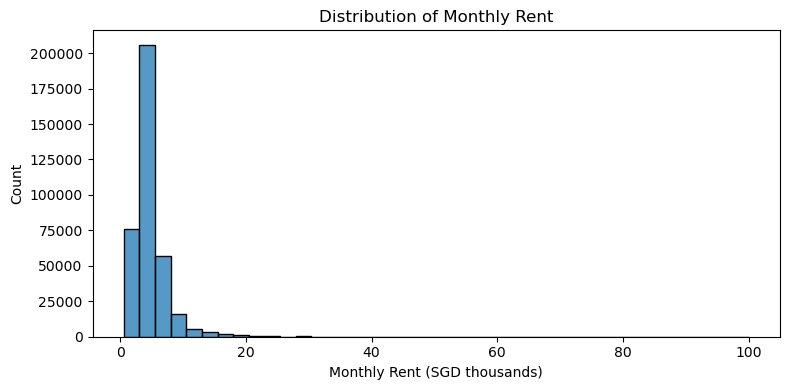

In [13]:
# Plot 1 Month Rent Distribution, Sort the district in ascending order

# Create a figure and an axes object
fig, ax1 = plt.subplots(figsize=(8,4))
sns.histplot(rental_2125['mth rent'], bins=40)
sns.set_palette('tab10')
ax1.set_title('Distribution of Monthly Rent')
ax1.set_xlabel('Monthly Rent (SGD thousands)')
ax1.set_ylabel('Count')
plt.tight_layout() # Improves layout of subplots
plt.show()


The distribution is left or positive as there are some outliers of high rent on the right.

Correct the distribution of data with the outlier of more than > 20 thousand dropped.


In [14]:
# Clean the data set,remove very high rent that cause the long tail

rental_2125 = rental_2125[rental_2125['mth rent'] < 20].copy()

# Drop Floor Area exceeding 400 sq m
rental_2125 = rental_2125[rental_2125['area_sm'] <= 400].copy()

# Drop off Properties with no bedrooms or more than 5
rental_2125 = rental_2125[(rental_2125['bedroom'] > 0 ) & (rental_2125['bedroom'] <= 5)].copy()
bedroom_counts = rental_2125['bedroom'].value_counts().sort_index()
print(f"Total number of bedroom transactions: {bedroom_counts.sum()}")


Total number of bedroom transactions: 366621


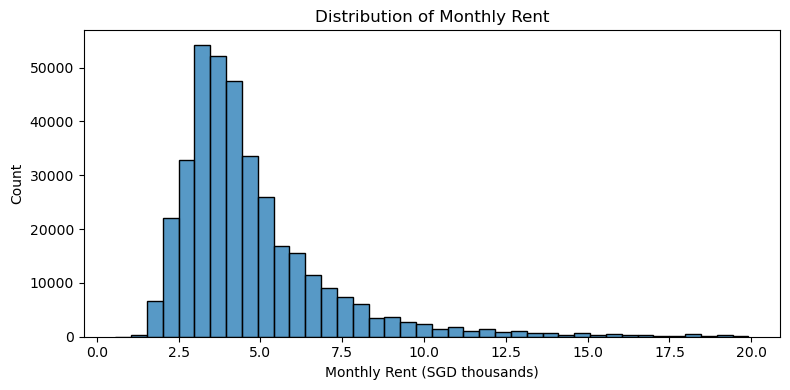

In [15]:
# Redo Plot 1 Month Rent Distribution

fig, ax1 = plt.subplots(figsize=(8,4))
sns.histplot(rental_2125['mth rent'], bins=40)
sns.set_palette('tab10')
ax1.set_title('Distribution of Monthly Rent')
ax1.set_xlabel('Monthly Rent (SGD thousands)')
ax1.set_ylabel('Count')
plt.tight_layout() # Improves layout of subplots
plt.show()


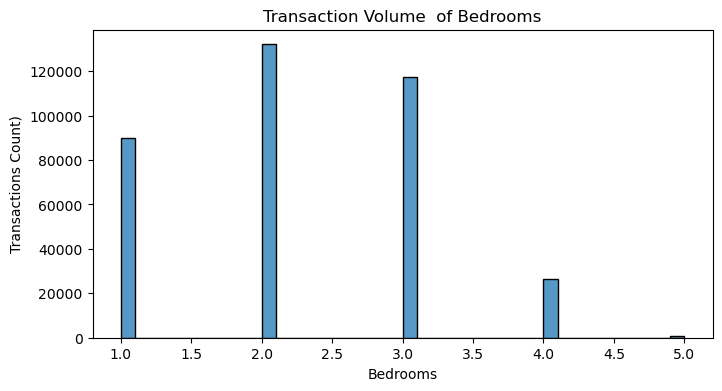

In [16]:
# Plot  Rent by bedroom count (historam plot )

fig, ax1 = plt.subplots(figsize=(8,4))
sns.histplot(rental_2125['bedroom'], bins=40)
sns.set_palette('tab10')
ax1.set_title('Transaction Volume  of Bedrooms')
ax1.set_xlabel('Bedrooms')
ax1.set_ylabel('Transactions Count)')
plt.tight_layout
plt.show()


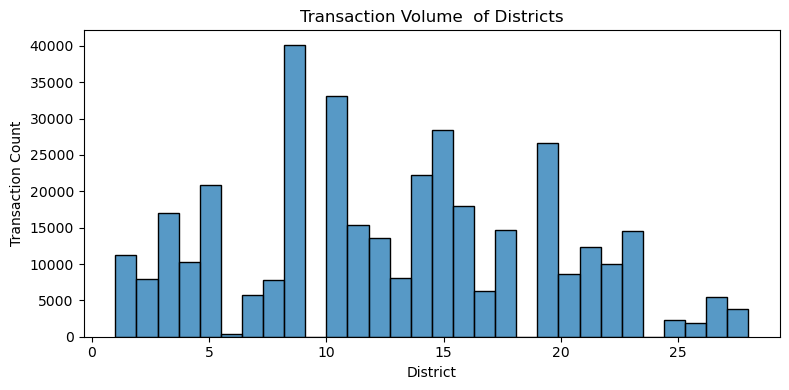

In [17]:
# Plot District count (historam plot )

plt.figure(figsize=(8,4))
sns.histplot(rental_2125['district'], bins=30)
sns.set_palette('tab10')
plt.title('Transaction Volume  of Districts')
plt.xlabel('District')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()


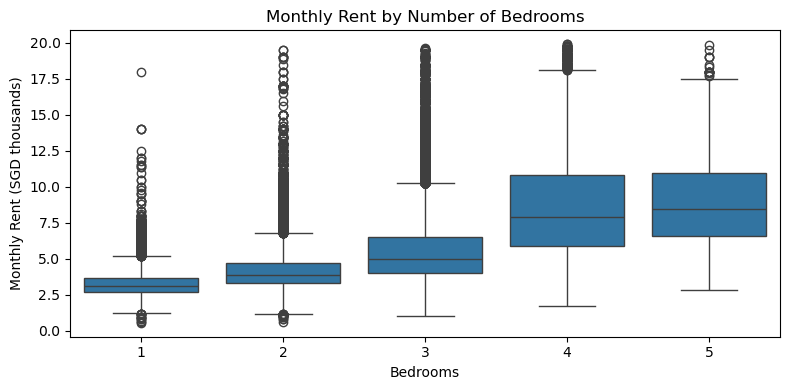

In [18]:
# Plot of Monthly Rent vs Number of Bedrooms

plt.figure(figsize=(8, 4))
bedroom_order = sorted(rental_2125['bedroom'].unique())
sns.boxplot(data=rental_2125, x='bedroom', y='mth rent',
            order=bedroom_order)
plt.title('Monthly Rent by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Monthly Rent (SGD thousands)')
plt.tight_layout()
plt.show()


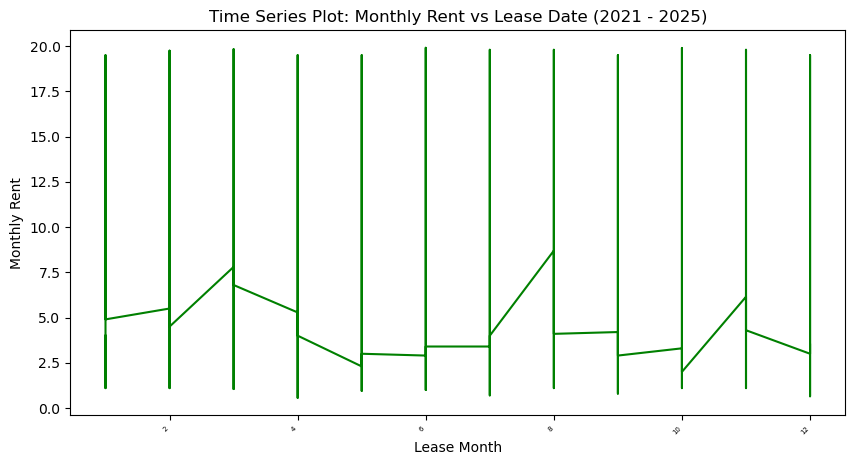

In [19]:
# A Time Series plot of Monthly Rent vs Lease Date from 2021-2025, Sort the data by lease date

rental_2125 = rental_2125.sort_values(by='lease_month').copy()
plt.figure(figsize=(10, 5))
plt.plot(rental_2125['lease_month'], rental_2125['mth rent'], color='green')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.title('Time Series Plot: Monthly Rent vs Lease Date (2021 - 2025)')
plt.xlabel('Lease Month')
plt.ylabel('Monthly Rent')
plt.tight_layout
plt.show()


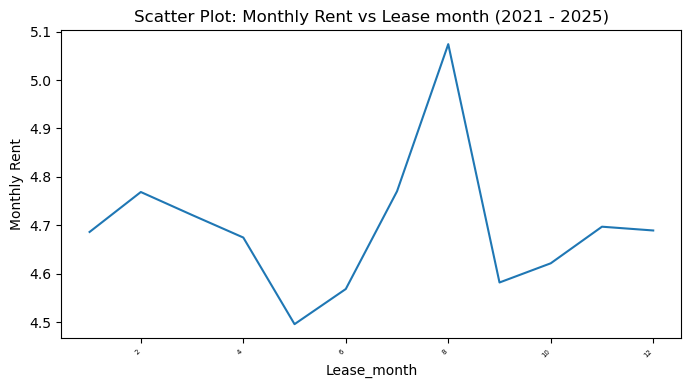

In [20]:
# Time Series Monthly Trend Plot to see trend of rental transaction

mthly_trend = rental_2125.groupby('lease_month')['mth rent'].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.plot(mthly_trend['lease_month'],mthly_trend['mth rent'])
plt.title('Scatter Plot: Monthly Rent vs Lease month (2021 - 2025)')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.xlabel('Lease_month')
plt.ylabel('Monthly Rent')
plt.tight_layout
plt.show()


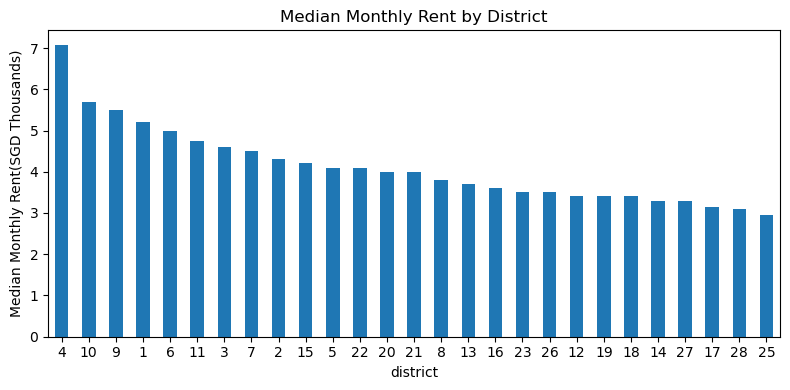

In [21]:
#Plot of Median rent by district

plt.figure(figsize=(8, 4))
district_avg = rental_2125.groupby('district')['mth rent'].median().sort_values(ascending=False)
district_avg.plot(kind='bar')
plt.title('Median Monthly Rent by District')
plt.ylabel('Median Monthly Rent(SGD Thousands)')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


(366621, 9)


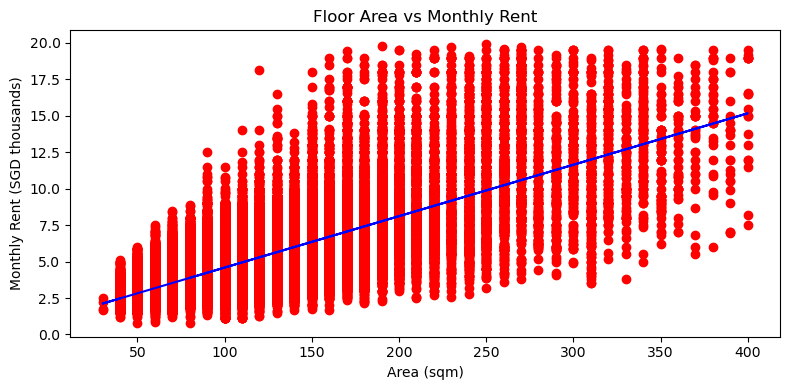

In [22]:
# Plot of Area vs Rent scatter (random sample of 30 percent of data set for  readability)

print(rental_2125.shape) # size of data set

# Plot Floor Area vs Monthly Rent
plt.figure(figsize=(8, 4))
rent_sample = rental_2125.sample(120000, random_state=42)
plt.scatter(rent_sample['area_sm'], rent_sample['mth rent'], color='red')
plt.title(' Floor Area vs Monthly Rent')
plt.xlabel('Area (sqm)')
plt.ylabel('Monthly Rent (SGD thousands)')

# ployfit = Fit the data using least squares polynomial regression ,# Returns a list of the coefficients

coefficients  = np.polyfit(rent_sample['area_sm'], rent_sample['mth rent'], 1)

#Use the coefficients to create a polynomial

line_x = np.poly1d(coefficients)

#Evaluate the polynomial on the monthly rent data

rent_sample['best_fit'] = line_x(rent_sample.loc[:, 'area_sm'])

# Add the line to the plot and fit using degree 1 polynomial
plt.plot(rent_sample['area_sm'], rent_sample['best_fit'], color='blue')
plt.xlabel("Area (sqm)")
plt.ylabel("Monthly Rent (SGD thousands)")
plt.title("Floor Area vs Monthly Rent")
plt.tight_layout()
plt.show()


Districts Observation:
District 4 includes Harbourfront, Telok Blangah, Keppel Bay and Sentosa island have the highest median rent.The higher median rent is probably attributed to properties proximity to downtown financial centre and technological business park at Alexandra.

## Correlations Heatmap for correlations efficient between features and predicted value.


**Features Selection, Correlation and Features Relationship**

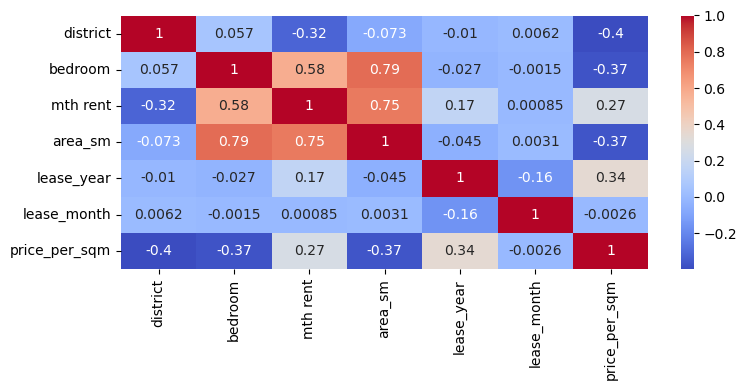

In [23]:
# Correlation Heatmap

plt.figure(figsize=(8, 4))
fig.suptitle('Feature Relationships')
# Select only numeric columns for correlation calculation
numeric_cols = rental_2125.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()


**Training Features Processing**

In [24]:
# Data preparation for SageMaker training jobs.
# District is one-hot encoded here so the training jobs receive a numeric matrix.

dummies = pd.get_dummies(rental_2125["district"], prefix="dist", drop_first=False, dtype=int)

rental_2125 = pd.concat(
    [rental_2125.drop(columns=dummies.columns, errors="ignore"), dummies],
    axis=1
)

# lease_month may already be numeric after the cleaning stage.
if not pd.api.types.is_numeric_dtype(rental_2125["lease_month"]):
    rental_2125["lease_month"] = pd.to_datetime(rental_2125["lease_month"]).dt.month

if "lease_year" not in rental_2125.columns:
    rental_2125["lease_year"] = 2025

print(rental_2125.head())


                        project                  street  district  bedroom  \
368876                SELETARIS          SEMBAWANG ROAD        27        3   
368877            HARBOURLIGHTS      TELOK BLANGAH ROAD         4        2   
368878          SYMPHONY SUITES            YISHUN CLOSE        27        2   
368879  SPOTTISWOODE RESIDENCES  SPOTTISWOODE PARK ROAD         2        1   
368880              THE TROPICA       TAMPINES AVENUE 1        18        4   

        mth rent  area_sm  lease_year  lease_month  price_per_sqm  dist_1  \
368876       4.0      150        2025            1         26.667       0   
368877       3.7       70        2025            1         52.857       0   
368878       3.0       70        2025            1         42.857       0   
368879       3.8       60        2025            1         63.333       0   
368880       5.0      150        2025            1         33.333       0   

        ...  dist_18  dist_19  dist_20  dist_21  dist_22  dist_23  d

In [25]:
# Split the final numeric training matrix.
Prop_features = ["bedroom", "area_sm", "lease_month", "lease_year"]
feature_columns = Prop_features + list(dummies.columns)

x = rental_2125[feature_columns].copy()
y = rental_2125["mth rent"].copy()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

train_df = x_train.copy()
train_df["mth rent"] = y_train

test_df = x_test.copy()
test_df["mth rent"] = y_test

train_local = "train.csv"
test_local = "test.csv"

train_df.to_csv(train_local, index=False)
test_df.to_csv(test_local, index=False)

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))
print("Features  :", feature_columns)


Train rows: 293296
Test rows : 73325
Features  : ['bedroom', 'area_sm', 'lease_month', 'lease_year', 'dist_1', 'dist_2', 'dist_3', 'dist_4', 'dist_5', 'dist_6', 'dist_7', 'dist_8', 'dist_9', 'dist_10', 'dist_11', 'dist_12', 'dist_13', 'dist_14', 'dist_15', 'dist_16', 'dist_17', 'dist_18', 'dist_19', 'dist_20', 'dist_21', 'dist_22', 'dist_23', 'dist_25', 'dist_26', 'dist_27', 'dist_28']


Why use Random Forest Regressor
1. Reduces Overfitting: Combines multiple decision trees to produce more stable predictions.
2. Robust to Outliers: Averaging predictions from many trees reduces the effect of extreme values.
3. Works with large datasets which is this case 369000 lines of data











**Logging Metrics MAE,RMSE, R2 Score to select Model for Registration**

In [26]:
# 5. SAGEMAKER MANAGED MLFLOW SETUP

# Use the SageMaker Managed MLflow App instead of local SQLite.
mlflow.set_tracking_uri(mlflow_app_arn)

# Experiment name
experiment_name = "Team08-s801-Training"

mlflow.set_experiment(experiment_name)

print("MLflow tracking URI:")
print(mlflow.get_tracking_uri())

print("MLflow experiment:")
print(experiment_name)


MLflow tracking URI:
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-WLHEEZL7YYAH
MLflow experiment:
Team08-s801-Training


In [27]:
#Evaluation Function 

results = {}


def evaluate(name, model, x_te, y_te):

    # Make prediction
    pred = model.predict(x_te)

    # Calculate metrics
    mae = mean_absolute_error(y_te, pred)

    rmse = np.sqrt(
        mean_squared_error(y_te, pred)
    )

    r2 = r2_score(
        y_te,
        pred
    )

    # Store results
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    # Print results
    print(
        f"{name:28s} "
        f"MAE={mae:.3f}  "
        f"RMSE={rmse:.3f}  "
        f"R2={r2:.3f}"
    )

    # Log metrics to current MLflow run
    mlflow.log_metrics({
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    return pred


**Experiment 1 Random Forest with default parameters**

In [28]:
# Experiment 1: Random Forest baseline -- LOCAL TRAINING
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

with mlflow.start_run(
    run_name="RF_Baseline"
) as run:

    rfmodel = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # Train
    rfmodel.fit(
        x_train,
        y_train
    )

    # Parameters
    mlflow.log_params({
        "model": "RandomForestRegressor",
        "model_type": "RF_Baseline",
        "n_estimators": 100,
        "random_state": 42
    })

    # Evaluate
    pred_rf = evaluate(
        "RF Baseline",
        rfmodel,
        x_test,
        y_test
    )

    print("Run ID:", run.info.run_id)



RF Baseline                  MAE=0.661  RMSE=1.052  R2=0.795
Run ID: d9030b5c472540a7be3fd69feeb993c6


🏃 View run RF_Baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8/runs/d9030b5c472540a7be3fd69feeb993c6
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8


**Experiment 2 Random Forest with Hyperparameter Tuning on depth 10, 20 and number of iteration at 100,150.**

In [29]:
# Experiment 2: Random Forest hyperparameter tuning -- LOCAL TRAINING
from sklearn.model_selection import RandomizedSearchCV


# RANDOM FOREST TUNING - 120,000 SAMPLE

print("TRAINING RF TUNED")


rf_sample_size = 120000

# Don't request more rows than available
rf_sample_size = min(
    rf_sample_size,
    len(x_train))

# Sample training data

rf_tune_sample = x_train.sample(
    n=rf_sample_size,
    random_state=42)

# Get matching target rows
y_rf_tune_sample = y_train.loc[
    rf_tune_sample.index]

print(
    "RF tuning training samples:",
    len(rf_tune_sample))

# RF base model

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)



# Smaller parameter search


param_dist = {
    "n_estimators": [150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]}


rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,

    # test 10 combinations
    n_iter=10,

    # 3-fold cross validation
    cv=3,

    scoring="neg_root_mean_squared_error",

    # Use all available CPU cores
    n_jobs=-1,

    random_state=42,

    verbose=1)

# Train RF tuned

rf_search.fit(
    rf_tune_sample,
    y_rf_tune_sample)

# Get best RF

best_rf = rf_search.best_estimator_

print("\nBest RF parameters:")
print(rf_search.best_params_)

# MLflow

with mlflow.start_run(
    run_name="RF_Tuned_120000") as run:

    mlflow.log_params({
        "model": "RandomForestRegressor",
        "model_type": "RF_Tuned",
        "training_sample_size": rf_sample_size,
        "cv": 3,
        "n_iter": 10,
        **rf_search.best_params_})

    # Evaluate on the ORIGINAL test set
    pred_rf_tuned = evaluate(
        "RF Tuned",
        best_rf,
        x_test,
        y_test)

    print("Run ID:", run.info.run_id)

TRAINING RF TUNED
RF tuning training samples: 120000
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best RF parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


RF Tuned                     MAE=0.676  RMSE=1.054  R2=0.795
Run ID: 54f079503d3c44a7b361ff4a8227979a


🏃 View run RF_Tuned_120000 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8/runs/54f079503d3c44a7b361ff4a8227979a
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8


With Random Forest Regressor algorithm after hyperparameter fine tuning the R2 is at approximately 0.8

**Experiment 3 with Gradient Boosting, XGBoostRegressor at max_depth 6 and iternation 300,350,400**

In [30]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.xgboost


# XGBoost training sample

print("TRAINING XGBOOST")

sample_size = 120000

# Minimum sample size

sample_size = min(
    sample_size,
    len(x_train))

# Sample x_train

xgb_sample = x_train.sample(
    n=sample_size,
    random_state=42)

# Select matching y rows

y_xgb_sample = y_train.loc[
    xgb_sample.index
]


print(
    "XGBoost training samples:",
    len(xgb_sample)
)


# XGBoost model

with mlflow.start_run(
    run_name="XGBoost_120000") as run:

    xgbmodel = XGBRegressor(
        n_estimators=400,
        learning_rate=0.2,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror")


    # Parameters
    mlflow.log_params({
        "model": "XGBRegressor",
        "training_sample_size": sample_size,
        "n_estimators": 350,
        "learning_rate": 0.2,
        "max_depth": 6,
        "random_state": 42})

  
    # Train ONLY on 120,000 rows
    

    xgbmodel.fit(
        xgb_sample,
        y_xgb_sample)


    # Evaluate against ORIGINAL TEST SET
   
    pred_xgb = evaluate(
        "XGBoost",
        xgbmodel,
        x_test,
        y_test)


    print("Run ID:", run.info.run_id)


TRAINING XGBOOST
XGBoost training samples: 120000


XGBoost                      MAE=0.642  RMSE=1.014  R2=0.810
Run ID: 721bb62f8d9d4de882254582561b3650


🏃 View run XGBoost_120000 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8/runs/721bb62f8d9d4de882254582561b3650
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/8


**Training architecture:** All Random Forest and XGBoost training runs execute locally on the SageMaker Studio compute instance. MLflow tracking is managed by the SageMaker MLflow App using `mlflow_app_arn`, instead of a local SQLite tracking database.

In [31]:
#SIMPLE MODEL COMPARISON

print("FINAL MODEL COMPARISON")

for name, metrics in results.items():

    print(
        f"{name:28s} "
        f"MAE={metrics['MAE']:.3f}  "
        f"RMSE={metrics['RMSE']:.3f}  "
        f"R2={metrics['R2']:.3f}")

#BEST MODEL FOR EACH METRIC

best_mae = min(
    results,
    key=lambda x: results[x]["MAE"])

best_rmse = min(
    results,
    key=lambda x: results[x]["RMSE"])

best_r2 = max(
    results,
    key=lambda x: results[x]["R2"])


print("\nBest model based on MAE : ", best_mae)
print("Best model based on RMSE: ", best_rmse)
print("Best model based on R2  : ", best_r2)

# Result

results_df = pd.DataFrame(results).T

display(results_df)

FINAL MODEL COMPARISON
RF Baseline                  MAE=0.661  RMSE=1.052  R2=0.795
RF Tuned                     MAE=0.676  RMSE=1.054  R2=0.795
XGBoost                      MAE=0.642  RMSE=1.014  R2=0.810

Best model based on MAE :  XGBoost
Best model based on RMSE:  XGBoost
Best model based on R2  :  XGBoost


,MAE,RMSE,R2
RF Baseline,0.660725,1.052011,0.795315
RF Tuned,0.675882,1.053702,0.794656
XGBoost,0.642393,1.014421,0.809681


**Verify MLFlow Experiment**

In [32]:
# Open the SageMaker MLflow App UI
# ============================================================
# AWS CLIENTS
# ============================================================

sm_client = boto3.client("sagemaker", region_name=REGION)
s3_client = boto3.client("s3", region_name=REGION)
s3_resource = boto3.resource("s3", region_name=REGION)


mlflow_url_response = sm_client.create_presigned_mlflow_app_url(
    Arn=mlflow_app_arn 
)

mlflow_ui_url = mlflow_url_response["AuthorizedUrl"]

print("MLflow App:", mlflow_app_arn)
print("MLflow Experiment:", experiment_name)
print("\nOpen this URL in your browser to view the MLflow run:")
print(mlflow_ui_url)


MLflow App: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-WLHEEZL7YYAH
MLflow Experiment: Team08-s801-Training

Open this URL in your browser to view the MLflow run:
https://app-WLHEEZL7YYAH.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjI0T1dKViIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNFRvcS9MTmRNUjVvbjlPVUlYUGJuWlNuM1dNbC9PUEgzLzlmVTQwZlVsNWtBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGclNIWlhaa040VWtOWWEzTnBiWEJqTW5aWlduY3llRXRpTjJaU1dEQXpaak56WVM5cGRHd3lTbmhHYmxwdlJYZElRbXA2ZEhrMGVtZFhjemQ0T1ZONlFUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFaVEhETEJLaXpnRU1DRnZsd0NZcjM4QUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6RUdTVVhHa3hIbWpBYjM1c0NBUkNBTzQ2dW5EMnk2a3VUVUxkczVCbEhMVGdnNWlxYT

In [33]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (26 kB)


  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)


Using cached shap-0.52.0-cp312-abi3-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (498 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)


  Attempting uninstall: numpy


    Found existing installation: numpy 1.26.4


...

   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]

   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 2/3 [shap]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-features 1.5.0

Note: you may need to restart the kernel to use updated packages.


In [34]:

# SHAP ANALYSIS - XGBOOST


import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("XGBOOST SHAP ANALYSIS")


# Use a small sample of the TEST data


SHAP_SAMPLE_SIZE = 3000

X_shap = x_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(x_test)),
    random_state=42)

print("SHAP sample size:", len(X_shap))
print("Number of features:", X_shap.shape[1])


# Create SHAP explainer


explainer = shap.TreeExplainer(xgbmodel)

# Calculate SHAP values

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed.")



#Feature importance


shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap.columns).sort_values(
    ascending=False)

print("\nTop 15 features:")
display(shap_importance.head(15))

XGBOOST SHAP ANALYSIS
SHAP sample size: 3000
Number of features: 31


SHAP calculation completed.

Top 15 features:


area_sm        0.954061
lease_year     0.457153
bedroom        0.255976
dist_9         0.223494
dist_10        0.142252
lease_month    0.099333
dist_1         0.091058
dist_4         0.081498
dist_3         0.070812
dist_19        0.064898
dist_2         0.054978
dist_23        0.051689
dist_18        0.044742
dist_16        0.041770
dist_11        0.034621
dtype: float32

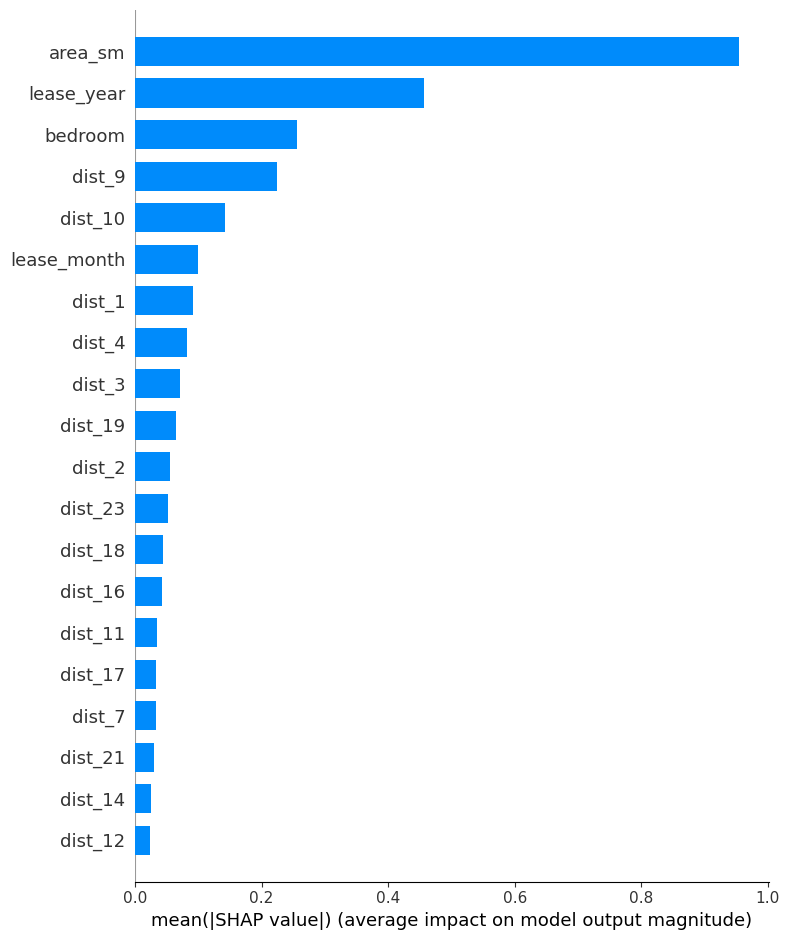

In [35]:
# SHAP FEATURE IMPORTANCE


shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_importance.png",
    dpi=150,
    bbox_inches="tight")

plt.show()

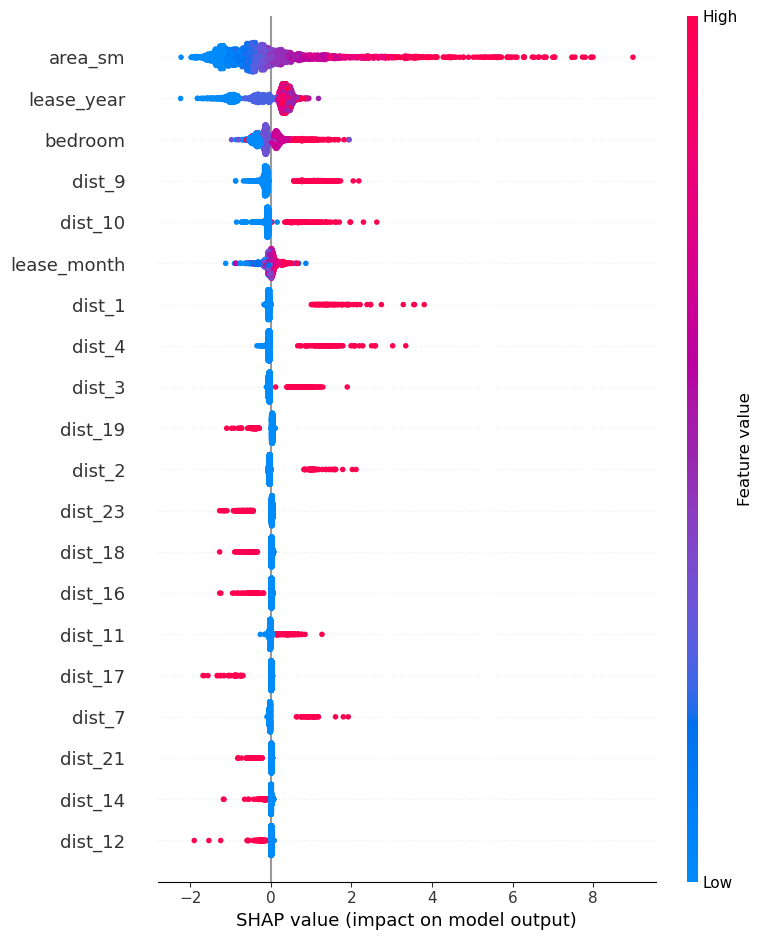

In [36]:
# SHAP BEESWARM

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

**End of EDA, Experiment and Shapley Analysis**